# Tutorial: Generating SMILES strings with SmileyLlama

Let's walk through a basic tutorial on how to use SmileyLlama to generate SMILES strings of molecules.

For reference, a [SMILES string](https://www.daylight.com/dayhtml/doc/theory/theory.smiles.html) offers a way to represent molecules as a string of characters. To represent a molecule, SMILES strings denote which atoms are connected to which other atoms, and (if necessary) the stereochemistry of their connections. Atoms are represented by their symbols. For instance, the letter `C` represents Carbon, the letter `O` represents Oxygen, and so forth. Hydrogens are generally assumed to be implicit. Two atomic symbols next to each other are assumed to be bonded; double bonds can be represented with `=` and triple bonds with `#`. So, for example, the SMILES string `CC` represents ethane, `C=C` represents ethylene, and `C#C` represents acetylene. Connections forming rings can be represented with numbers. For instance, cyclohexane can be represented with `C1CCCCC1`, with the 1's indicating that the first and last carbons are bonded to each other. Branches can also be represented using parentheses. For instance isopropyl alcohol may be represented as `CC(O)C`. Aromaticity is denoted by lowercase letters, for instance `c1ccccn1` represents pyridine. Far more rules than these exist, and more comprehensive tutorials and documentation can be found online, for instance at [Daylight's website](https://www.daylight.com/dayhtml/doc/theory/theory.smiles.html), but this should help understand the majority of SMILES strings generated by SmileyLlama.


We can use [RDKit](https://www.rdkit.org/), a python library, to visualize these SMILES strings, as well as to compute their properties. We also need to import the necessary requirements for inference, namely pytorch and transformers.

In [1]:
import torch
import transformers
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Draw

After we've imported the required libraries, we can download the weights. This should work if the computer is connected to the internet, but it takes a while. It's generally far faster to specify the path to the model if it's already downloaded for the `model_id` variable.

We can also set up the "pipeline", which will let us pass in a prompt, plus some parameters, to generate SMILES strings with SmileyLlama. We're loading the model using the bfloat-16 number format. This means that an 8GB model like SmileyLlama will take up **at least 16 GB of memory**.

In [2]:
model_id = "THGLab/Llama-3.1-8B-SmileyLlama-1.1"

In [ ]:
pipeline = transformers.pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map='auto' #This can cause problems. Removing it won't break anything, but will lead to running on CPU
)

Now, let's create a prompt and run some inference! Note that the prompt format here is in the Alpaca format. This is due to how axolotl structured the prompts during SFT and DPO. The system text generally represents the "role" that SmileyLlama plays. This system prompt was used all throughout the SmileyLlama project. The user prompt here is pretty generic, but soon we'll change it to specify properties that SmileyLlama ought to generate molecules with.

In [4]:
system_text = "You love and excel at generating SMILES strings of drug-like molecules"
user_text = "Output a SMILES string for a drug like molecule:"
prompt = f"### Instruction:\n{system_text}\n\n### Input:\n{user_text}\n\n### Response:\n"

We can generate a SMILES string with the following code. One thing to note is that we're setting `do_sample` to `False`, which causes SmileyLlama to deterministically generate the most likely next token. We're currently doing this for the sake of our demo; in most practical cases we want diversity for SmileyLlama's generations, so we generally don't include this. (`do_sample` is set to `True` by default). We also unset `temperature` and `top_p`, which are both parameters which determine how the next token is probabalistically sampled, and so aren't relevant in this case.

We can also specify the maximum number of new tokens to generate. Like Llama, SmileyLlama will stop generating text after it generates a "stop token". However, we can also enforce a stop after a certain number of new tokens with `max_new_tokens`.

In [5]:
outputs = pipeline(
    prompt,
    max_new_tokens=128,
    temperature=None,
    top_p=None,
    num_return_sequences=1,
    do_sample=False
)

Now that we've generated a SMILES string, let's print and visualize it! RDKit lets us do this very easily.

c1c(ccc(c1)C)C1C2C(C(=O)N1c1ccc(cc1)C)C1C(C(=O)N(C)C1=O)C2=O 




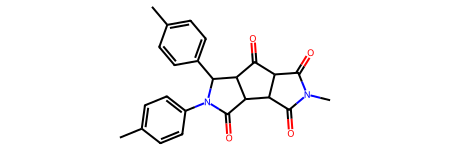

In [6]:
smiles_string = outputs[0]['generated_text'].splitlines()[-1]
print(smiles_string, '\n\n')
rdkit.Chem.MolFromSmiles(smiles_string)

OK, that's all well and good, but what about generation from a prompt? For instance, what if we want to generate a molecule with the following substructure?

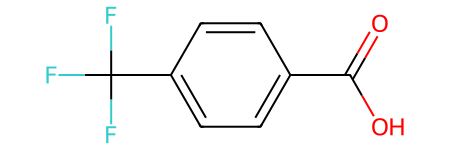

In [7]:
Chem.MolFromSmiles('O=C(O)c1ccc(C(F)(F)F)cc1')

Let's try asking SmileyLlama! We can specify a substructure in the 

In [8]:
conditional_user_text = 'Output a SMILES string for a drug like molecule with the following properties: a substructure of O=C(O)c1ccc(C(F)(F)F)cc1, <= 500 Molecular weight, <=5 LogP, <= 5 H-bond donors, <= 10 H-bond acceptors'
prompt = f"### Instruction:\n{system_text}\n\n### Input:\n{conditional_user_text}\n\n### Response:\n"

c1c(ccc(C(F)(F)F)c1)C(OCC(=O)Nc1cc2c(cc1)OCO2)=O 




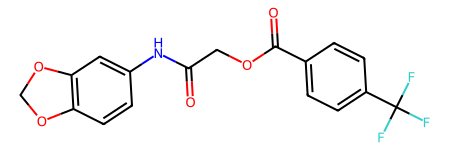

In [9]:
outputs = pipeline(
    prompt,
    max_new_tokens=128,
    temperature=None,
    top_p=None,
    num_return_sequences=1,
    do_sample=False
)
smiles_string = outputs[0]['generated_text'].splitlines()[-1]
print(smiles_string, '\n\n')
Chem.MolFromSmiles(smiles_string)

And here we see that it correctly generated a molecule with the given substructure. One interesting thing here is that it didn't "cheat" by simply copying the SMILES string of the substructure verbatim, then adding the rest of the molecule. This is likely due to the fact that, during training, the SMILES strings that SmileyLlama was trained to complete were randomized. This means that SmileyLlama couldn't learn to "cheat" in this manner during the training process, since the substructure SMILES strings given as hints in the prompt were often not substrings of the completions.

We can check whether it obeys the rule of five as well, and therefore the prompt, with the following code:

In [ ]:
def get_rule_of_five(smiles_string, verbose=True):
    mol = Chem.MolFromSmiles(smiles_string)
    
    hbd = Lipinski.NumHDonors(mol)
    print("H-bond donors", hbd)
    hba = Lipinski.NumHAcceptors(mol)
    print("H-bond acceptors", hba)
    mw = Descriptors.MolWt(mol)
    print("Molecular weight:", mw)
    logp = Descriptors.MolLogP(mol)
    print("logP:", logp)
    
    return hbd<=5 and hba<=10 and mw<=500 and logp<=5

In [11]:
obeys_rule_of_five = get_rule_of_five(smiles_string)
print("Obeys the Rule of Five: ", obeys_rule_of_five)

H-bond donors 1
H-bond acceptors 5
Molecular weight: 367.27900000000017
logP: 3.2296000000000022
Obeys the Rule of Five:  True


Now, let's try generating ten SMILES strings of molecules with a substructure of furfural (`c1cc(oc1)C=O`) with a molecular weight of $\leq 300$ Daltons. You can skip this next part if you're on a laptop or relatively cheap computer.

The `temperature` argument here controls how "random" the generation of SmileyLlama is. Make it too low, like `0.1` and you'll get the same strings most of the time. Make it too high and it will frequently generate invalid strings and SMILES which disobey the prompt. Extremely high temperatures produce nonsense, just like with any other autoregressive transformer LLM.

`num_return_sequences` determines how many SMILES strings are produced at once. Making this number too high will tax memory, so be careful!

In [12]:
conditional_user_text = 'Output a SMILES string for a drug like molecule with the following properties: a substructure of c1cc(oc1)C=O, <= 300 Molecular weight:'
prompt = f"### Instruction:\n{system_text}\n\n### Input:\n{conditional_user_text}\n\n### Response:\n"

outputs = pipeline(
    prompt,
    max_new_tokens=128,
    num_return_sequences=4,
    temperature=1.0
)
smiles_strings = [response['generated_text'].splitlines()[-1] for response in outputs]
for s in smiles_strings:
    print(s)

c1cc(C)c(NC(=O)c2occc2)cc1OC(F)F
C(OCCN1CCCC1)(=O)c1ccco1
C(=O)(c1c(cccc1)OC)N1CCN(C(c2ccco2)=O)CC1
c1cc(cc(OC)c1OC)/C=C1\COC(=O)c2c(oc(C=O)c2)C1


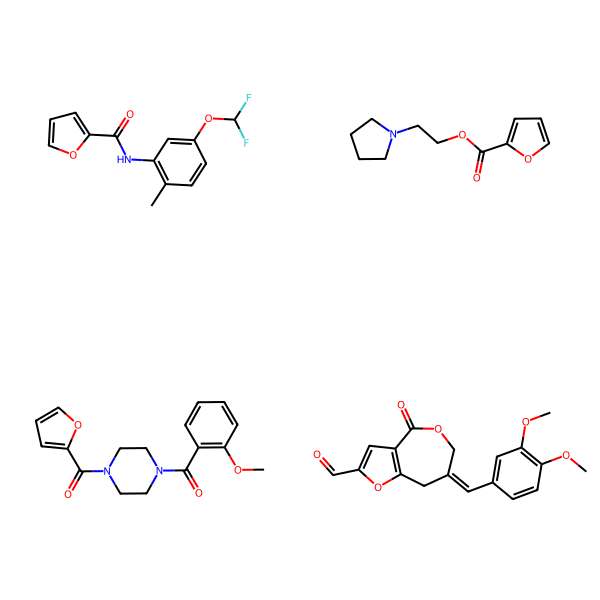

In [13]:
mols = [Chem.MolFromSmiles(s) for s in smiles_strings]
Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(300,300))

It's also possible to add other information and directions to the prompt, beyond what's shown in this tutorial. In addition, fine-tuned SmileyLlama models are available. 

`THGLab/Llama-3.1-8B-SmileyLlama-1.1-Prompt-Following` obeys instructions in the prompt more readily, and  `THGLab/Llama-3.1-8B-SmileyLlama-1.1-Mpro` will often generate molecules which dock well to SARS-CoV-2 Main protease.

Both have different and interesting behavior that was explored in the paper, but interacting with the models helps build an intuitive understanding of their strengths and weaknesses. Ultimately, there's no substitute for hands on experience, so we encourage you to explore with some prompts of your own!